# Jointly-trained LCM for KV cache compression

Meta's [Large Concept Models](https://arxiv.org/pdf/2412.08821) replace next-token prediction with next concept-embedding prediction. The architecture has three stages: a token-to-concept encoder, a concept-level decoder, and a concept-to-token decoder. By operating on concept embeddings instead of tokens, the KV cache for the concept decoder scales as $L / k$ instead of $L$, where $k$ is the concept size in tokens. A jointly-trained variant was tested and found to underperform a standard transformer at all concept sizes, including concept_size=1 where no compression occurs.

## Architecture

The three stages are:

1. **Encoder.** Tokens attend to tokens in previous blocks via causal block masking, then a reduction operation collapses each block of $k$ tokens into a single concept embedding.
2. **Concept decoder.** Standard causal transformer over the sequence of concept embeddings.
3. **Token decoder.** Causal self-attention over tokens, plus cross-attention to concept embeddings from blocks $< i$.

All masks are combined with segment masks to prevent attention across packed sequence boundaries. The encoder mask uses strict inequality at the block level: tokens in block $i$ attend only to tokens in blocks $< i$. This prevents future leakage, since concept $i$ is consumed by the token decoder to predict tokens in block $i$.

Four reduction strategies were tested for collapsing tokens within a block:

| Strategy | Description |
|----------|-------------|
| Sum | Element-wise sum of token representations |
| Max | Element-wise max |
| Learned weighted sum | Learnable scalar weight per position within the block |
| Attention | Learnable query attends over block tokens |

Implementation: [`forward_pass`](../train.py#L370), [`encoder_block`](../train.py#L414), [`concept_decoder_block`](../train.py#L470), [`token_decoder_block`](../train.py#L530).

### Divergences from the LCM paper

| LCM paper | This implementation |
|-----------|---------------------|
| Pretrained SONAR encoder/decoder | Jointly trained from scratch |
| Dynamic sentence-level concepts (10--20 tokens, ≤200 chars) | Fixed-size token blocks |
| Diffusion-based concept decoder (best variant) | Autoregressive concept decoder only |

## What is actually compressed

The token decoder still runs full causal self-attention over all $L$ tokens. Only the cross-attention KV cache scales as $L/k$. The theoretical KV reduction at concept size $k$ is:

$$\frac{n_\text{self-attn} \cdot L + n_\text{cross-attn} \cdot L/k}{(n_\text{self-attn} + n_\text{cross-attn}) \cdot L}$$

At concept_size=8 with equal self-attention and cross-attention layers, this is a 56% reduction in KV bytes. No memory or latency measurements were taken; the results below are loss-only.

In [16]:
from clearml import Task
import matplotlib.pyplot as plt
import pandas as pd
import yaml

LCM_EXPERIMENT_IDS = [
    "58b7c60aa20e485d9c74a43819f720d5",
    "66b4c6f95b0e415aa26888bfc6efddf2",
    "ce8a074185ad4e91a9e9a721ff57f61a",
    "af54a412b286431fa2340e85c69ed293",
    "a7752a2b82254371a109e01c6661b271",
    "c6f92dce47d74c59a2a087aec3e34f41",
    "9c6b027deac04ce09822eecd02941420",
    "ca4c293546154ff9ad8da4446f22ddce",
    "e708aba99f9c4df7b21492e5b5366036",
    "cb467050886d4c0797d91ea6023ffd3d",
    "10e58923831e4f6e8efd18a8e00e83f8",
    "1d449329ac3f4d0fa3bf6d173f439c7b",
    "bb5b1ccedec745848754ca74ba60a28a",
    "0fd0a497fddf4223b7accdeecd5d6e35",
    "0bd01bebd9d340a29f691547dbf21426",
    "9d7ae33dd76e41f58e93a23ec123b7ca",
    "1c2d88bfe3a04e11829e693190c02001",
    "d3a41adb55954745b2a318ebc9032c1b",
    "7a72052b8b13468c9275ba29b822bfb1",
    "ad3801064a184e2994c25cf809c3dd8e",
    "f55f3b2c16d144e49104efa586c720fe",
    "65699e524fa949d28f0c230bab491975",
    "a9969ae1607743909d96ac01920c3450",
    "740a6bb93f154b2d8d6305f0a910017d",
    "a3ad577ce7b34c9d9d46e9817984a6a7",
    "71bd9272da784e24b873cdefc4b4e5bd",
    "a6e8960119474f9daad1965cdcfaac84",
    "1fd109b244e6495aae54884d573dacd3",
    "ff77efbccb104aba8f719d258cde91ad",
    "979eba69eb8545b8892061fcdc4fbeaa",
    "d9e0de8de9714db8ae5ba6676c4bfed8",
    "e537b35e73394fb18ff047099aeba1a0",
    "cf39a009b8a84a9484972b6243a6faea",
    "f069ba9c2af44d41ac9f550ec35c3cb5",
    "e2967be6923c48498717d9abcf48d983",
    "2e82d84d6977418483e6bd7b1675901a",
]

TRACKED_FIELDS = [
    ("block_size", "Block_Size"),
    ("layers", "Concept_Decoder_Layers"),
    ("n_e_layers", "Encoder_Layers"),
    ("n_t_layers", "Token_Decoder_Layers"),
    ("reduction_strategy", "Reduction_Strategy"),
    ("n_kv", "Attention_Heads"),
    ("learning_rate", "Learning_Rate"),
    ("d_model", "d_model"),
    ("d_ff", "d_ff"),
]


def calculate_ema(data, smoothing=0.97):
    ema = [data[0]]
    for value in data[1:]:
        ema.append(ema[-1] * smoothing + value * (1 - smoothing))
    return ema


def get_metrics_data(task_ids):
    metrics_data, config_data = {}, {}
    for task_id in task_ids:
        task = Task.get_task(task_id=task_id)
        config = yaml.safe_load(task.get_configuration_object("OmegaConf"))
        config_data[task_id] = {**config["model"], **config["training"]}
        scalar_logs = task.get_reported_scalars()
        if "loss" not in scalar_logs:
            continue
        metrics_data[task_id] = {
            "name": task.name.replace("model.", ""),
            "steps": scalar_logs["loss"]["loss"]["x"],
            "loss": scalar_logs["loss"]["loss"]["y"],
            "final_loss": scalar_logs.get("final_loss", {}).get("eval", {}).get("y"),
            "final_perplexity": scalar_logs.get("final_perplexity", {}).get("eval", {}).get("y"),
        }
    return metrics_data, config_data


def get_top_k_experiments(loss_data, k=None, ema_smoothing=0.97):
    sorted_exps = sorted(loss_data.items(), key=lambda x: calculate_ema(x[1]["loss"], smoothing=ema_smoothing)[-1])
    return dict(sorted_exps[:k] if k else sorted_exps)


def plot_loss_data(loss_data, plot_last=1000, ema_smoothing=0.97, top_k=None, opacity=0.25):
    if top_k:
        loss_data = get_top_k_experiments(loss_data, k=top_k, ema_smoothing=ema_smoothing)
    plt.figure(figsize=(10, 6))
    for _, data in loss_data.items():
        steps, loss = data["steps"][-plot_last:], data["loss"][-plot_last:]
        (line,) = plt.plot(steps, calculate_ema(loss, smoothing=ema_smoothing), label=data["name"])
        plt.plot(steps, loss, alpha=opacity, color=line.get_color())
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", fontsize="small", ncol=2)
    plt.minorticks_on()
    plt.grid(which="both", linestyle="--", linewidth=0.5)
    plt.show()


def get_eval_metrics_table(metrics_data, config_data):
    rows = []
    for guid, d in metrics_data.items():
        if d["final_loss"] is None:
            continue
        fields = {}
        for config_key, display_key in TRACKED_FIELDS:
            if config_key in config_data[guid]:
                val = config_data[guid][config_key]
                fields[display_key] = float(val) if config_key == "learning_rate" else (val if config_key == "reduction_strategy" else int(val))
        name = d["name"]
        rows.append({"Name": name if len(name) < 25 else name[:25] + "...", "Eval Loss": float(d["final_loss"][0]), **fields})
    df = pd.DataFrame(rows).sort_values("Eval Loss").reset_index(drop=True)
    return df.style.format(precision=6).set_properties(**{"text-align": "left"})


metrics_data, config_data = get_metrics_data(LCM_EXPERIMENT_IDS)

## concept_size=1 control

A 31M parameter model was trained on SlimPajama at sequence length 1024. The [baseline](../configs/slim_v4-32_31m.yaml) without any concept architecture outperforms every LCM variant across the full training run.

At concept_size=1, there is no compression: each concept embedding represents exactly one token. The reduction step is a no-op. Any gap between this configuration and the baseline is purely architectural overhead from the encoder, concept decoder, and cross-attention path. The gap exists, which means the degradation is not caused by compression. It is caused by the architecture.


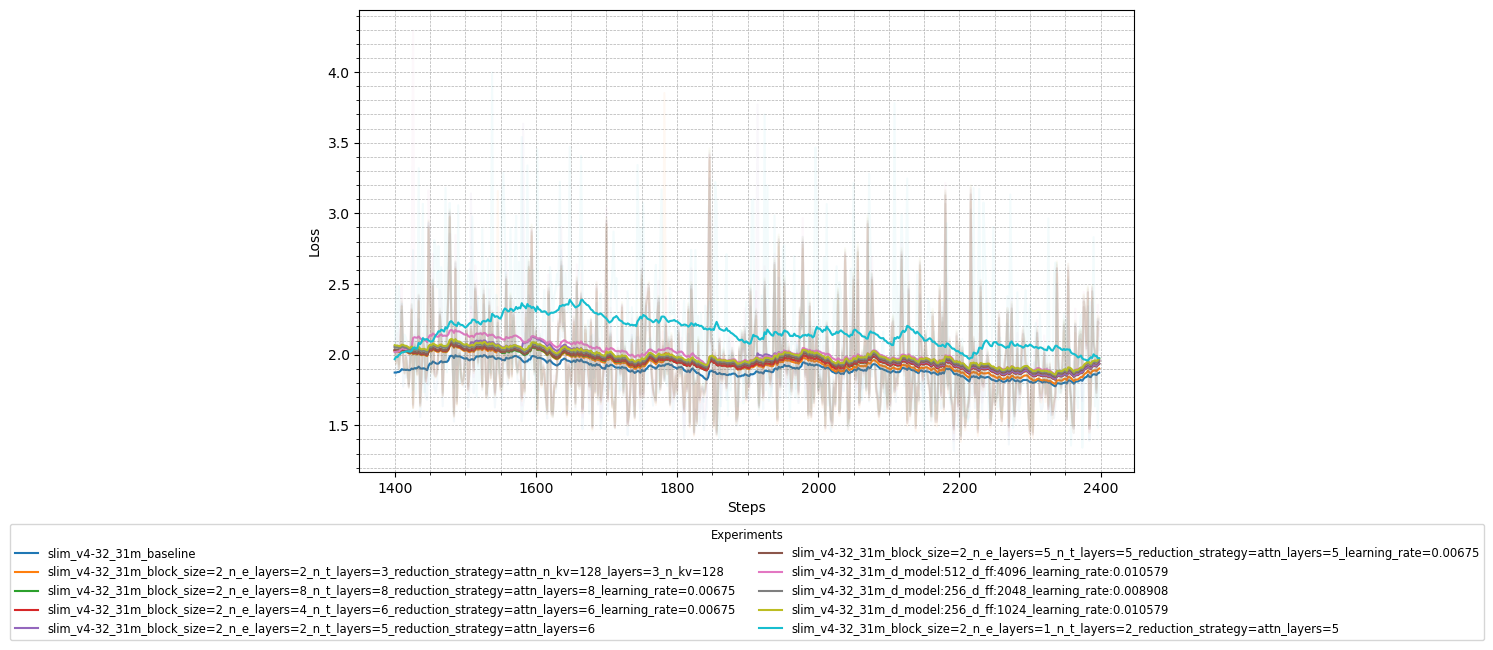

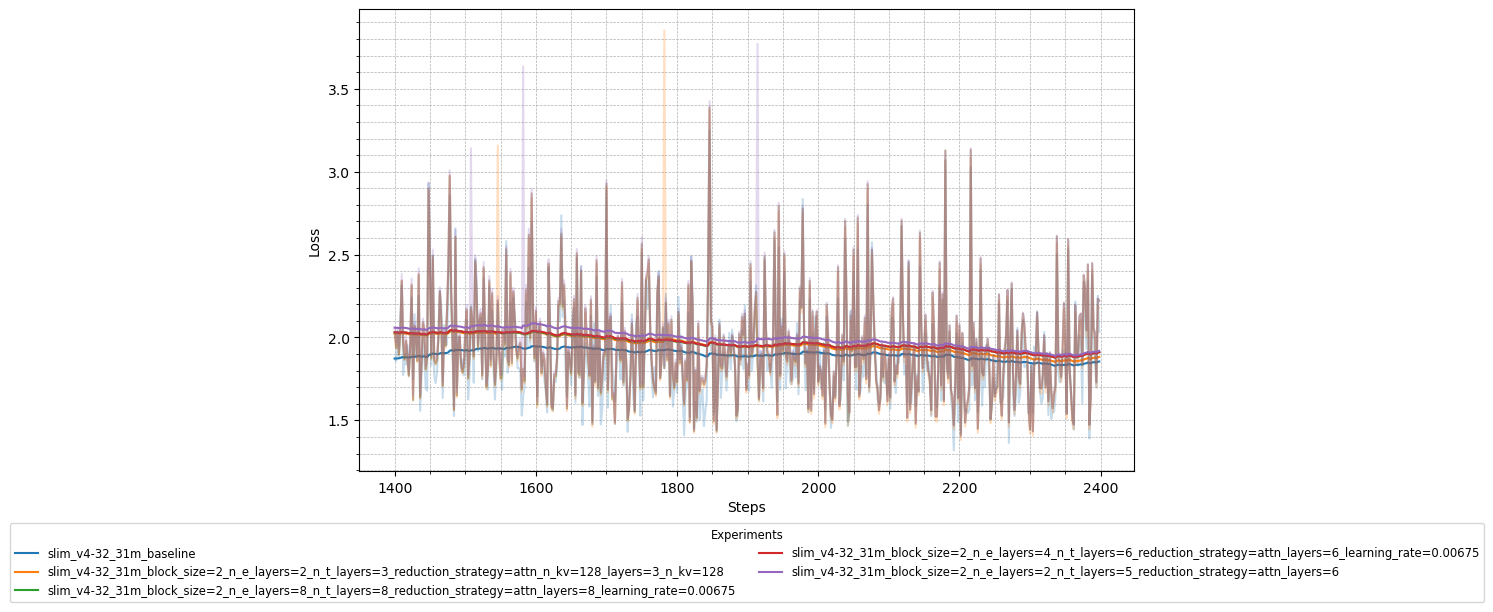

In [4]:
plot_loss_data(metrics_data, plot_last=500, ema_smoothing=0.97, top_k=10, opacity=0.05)
plot_loss_data(metrics_data, plot_last=500, ema_smoothing=0.99, top_k=5)

## Reduction strategies

Attention-based reduction is the only strategy that appears in the top 10 experiments. Sum, max, and learned weighted sum do not. This is expected: attention-based reduction is the closest to a standard transformer layer.

## Scaling compute

The gap persists on the validation set (240 samples) when scaling the LCM with 4--8x additional FLOPs:

| Scaling axis | Values tested |
|-------------|---------------|
| Attention heads | 32, 64, 128 |
| d_model | 384, 512 |
| d_ff | 4x d_model, 8x d_model |
| LCM depth | increased |

Additional capacity does not close the gap. Scaling heads to 64 or 128 also nullifies KV cache savings, since the concept decoder's own KV cache grows proportionally.

In [19]:
get_eval_metrics_table(metrics_data, config_data)

,Name,Eval Loss,Block_Size,Concept_Decoder_Layers,Encoder_Layers,Token_Decoder_Layers,Reduction_Strategy,Attention_Heads,Learning_Rate,d_model,d_ff
0,slim_v4-32_31m_baseline,1.849695,-,8,-,-,-,16,0.013500,256,1024
1,slim_v4-32_31m_block_size...,1.874595,2,3,2,3,attn,128,0.013500,256,1024
2,slim_v4-32_31m_block_size...,1.908515,2,8,8,8,attn,16,0.006750,256,1024
3,slim_v4-32_31m_block_size...,1.908937,2,6,4,6,attn,16,0.006750,256,1024
4,slim_v4-32_31m_block_size...,1.911174,2,6,2,5,attn,16,0.013500,256,1024
5,slim_v4-32_31m_block_size...,1.927374,2,5,5,5,attn,16,0.006750,256,1024
6,slim_v4-32_31m_d_model:51...,1.934949,2,3,2,3,attn,16,0.010579,512,4096
7,slim_v4-32_31m_d_model:25...,1.935532,2,3,2,3,attn,16,0.008908,256,2048
8,slim_v4-32_31m_block_size...,1.936809,2,3,3,3,attn,16,0.013500,256,1024
9,slim_v4-32_31m_d_model:25...,1.945458,2,3,2,3,attn,16,0.010579,256,1024


## Limitations

These results are from a single seed with 240 validation samples. The directional result is consistent across all configurations, but exact gap sizes are not reliable without bootstrap CIs over ≥1M tokens with multiple seeds.

Compute matching across LCM variants is approximate. The 4--8x FLOP range is a rough bound, not a controlled comparison along a single axis (parameters, training FLOPs, or inference FLOPs).

31M parameters at L=1024 is below the regime where LCM-style methods are expected to help. The LCM paper's claims center on long-context semantic compression. A negative result at this scale does not rule out the architecture at larger scales or longer contexts.

No experiment measures actual KV cache memory, prefill latency, or decode latency.

## Next experiments

The concept_size=1 result narrows the problem to the architecture but does not identify which component is responsible. The following ablations at concept_size=1 would decompose the gap:

| Ablation | What it isolates |
|----------|------------------|
| Skip concept decoder (encoder → token decoder directly) | Cost of the concept decoder |
| Identity encoder (concept decoder + cross-attention, no learned encoding) | Cost of the encoder |
| Tied weights across all three sub-networks | Cost of joint optimization |
| Initialize encoder/decoder from trained baseline | Joint training vs. architecture |

Other experiments in rough priority order: disable sequence packing to rule out concept boundary corruption from packed documents; increase context length to L=4096 where the LCM thesis applies; measure actual KV cache memory and latency to plot the loss-vs-KV-bytes Pareto frontier; add an auxiliary chunk-reconstruction loss to force concept embeddings to be informative.

## Appendix: LLM code review failure

`claude-opus-4-7-20250506` reviewed this code and classified two masks as "likely implementation bugs":

> `encoder_mask = chunk_indices[:, None] > chunk_indices[None, :]` (`train.py:538`) is a strict inequality. A token cannot attend to itself or to other tokens in its own chunk, so the encoder cannot mix tokens within a block — exactly the operation the encoder is supposed to do. This almost certainly should be `>=`.

> `x_causal_mask = q_pos // concept_size > k_pos` (`train.py:545`) prevents a token from cross‑attending to its own concept block. Whether that's intended (predicting chunk `i` from concepts `<i`) deserves an explicit sentence, because it materially changes what the LCM is doing.

The encoder produces concept $i$ from block $i$. The token decoder consumes concept $i$ to predict tokens in block $i$. With `>=`, tokens in block $i$ attend to themselves through the concept embedding, introducing future leakage. Training loss improves. Autoregressive quality degrades.
Accepting either fix without tracing the data flow introduces a silent correctness bug.